## Phase 2 baseline: logistic regression

Walks through `src/models/baseline_logistic_regression.py` step by step, reusing
its actual functions rather than re-deriving the logic here, so this notebook
stays tied to the reviewed/tested script instead of drifting into its own copy.

Goal: understand *what the baseline is doing and why it works reasonably well*,
not to add anything new — no changes to features, model, or evaluation happen
here. See `docs/concepts_log.md`'s 2026-09-16 entries for the full write-up of
logistic regression and class weighting.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import roc_curve

sys.path.append(str(Path.cwd().parent))
sys.path.append(str(Path.cwd().parent / "src"))

from models.baseline_logistic_regression import (
    BINARY_COLS,
    CONTINUOUS_COLS,
    FEATURE_COLS,
    evaluate,
    fit_baseline,
    load_train_val,
    prepare_features,
    print_coefficients,
    scale_continuous,
    top_k_lift,
)

PROJECT_ROOT = Path.cwd().parent

plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
pd.set_option("display.max_columns", None)

### Load train + val

Test stays untouched until the final reported number
(`docs/decisions/004-three-way-split.md`) — this baseline is fit on train and
sanity-checked on val only.

In [2]:
df = load_train_val()

by_split = df.groupby("split")["adoption"].agg(["size", "mean"])
by_split = by_split.rename(columns={"size": "rows", "mean": "adoption_rate"})
by_split

,rows,adoption_rate
split,,
train,7694326,0.006329
val,1751740,0.00438


### Feature set

16 of the Phase 2 engineered features. `renta_log` is used instead of
`renta_imputed` — both encode the same income value, and feeding a linear
model two collinear versions of the same signal just adds noise to the
coefficients without adding information.

Continuous features get standardized before fitting; the flag/one-hot columns
are already 0/1 and are left as-is.

In [3]:
print(f"{len(CONTINUOUS_COLS)} continuous:", CONTINUOUS_COLS)
print(f"{len(BINARY_COLS)} binary/one-hot:", BINARY_COLS)

6 continuous: ['tenure_months', 'activity_index', 'product_count_prev', 'age_years', 'age_years_sq', 'renta_log']
12 binary/one-hot: ['tenure_missing', 'activity_missing', 'product_count_missing', 'age_missing', 'sexo_h', 'sexo_v', 'sexo_missing', 'segmento_top', 'segmento_particulares', 'segmento_universitario', 'segmento_missing', 'renta_missing']


### Prepare features and target

`prepare_features` selects the feature matrix and casts pandas' nullable
`adoption` boolean to a plain int (sklearn wants numeric dtypes).

In [4]:
train_df = df[df["split"] == "train"]
val_df = df[df["split"] == "val"]

X_train, y_train = prepare_features(train_df)
X_val, y_val = prepare_features(val_df)

print(f"train: {X_train.shape}, adoption rate {y_train.mean():.3%}")
print(f"val:   {X_val.shape}, adoption rate {y_val.mean():.3%}")

train: (7694326, 18), adoption rate 0.633%
val:   (1751740, 18), adoption rate 0.438%


### Scale the continuous features

Logistic regression's gradient-based solver converges poorly when features
sit on very different scales — `renta_log` ranges roughly 11-17, while
`activity_index` is 0/1. `scale_continuous` fits a `StandardScaler` on
**train-only** statistics (same train-only rule as every imputation step so
far) and applies it to both train and val.

Below: one continuous column before and after scaling, to make the transform
concrete.

In [5]:
example_col = "renta_log"
before = X_train[example_col]

X_train_scaled, X_val_scaled, scaler = scale_continuous(X_train, X_val)

after = X_train_scaled[example_col]
pd.DataFrame({"before": before.describe(), "after": after.describe()})

,before,after
count,7.694326e+06,7.694326e+06
mean,1.154804e+01,5.726623e-07
std,5.755897e-01,1.000000e+00
min,7.093180e+00,-7.739643e+00
25%,1.122360e+01,-5.636654e-01
50%,1.153995e+01,-1.405021e-02
75%,1.184279e+01,5.120906e-01
max,1.717916e+01,9.783220e+00


### Fit the baseline

`class_weight="balanced"` reweights the loss so misclassifying a rare adopter
(~0.6% of rows) costs far more than misclassifying a non-adopter — without
it, the model has little incentive to separate the classes at all. See the
2026-09-16 "Class weighting for imbalanced classification" entry in
`docs/concepts_log.md`.

In [6]:
model = fit_baseline(X_train_scaled, y_train)
print(f"solver converged in {model.n_iter_[0]} iterations")

solver converged in 25 iterations


### Evaluate: ROC-AUC and top-1% lift

**ROC-AUC** answers: if you picked one random adopter and one random
non-adopter, how often does the model score the adopter higher? 0.5 is random
guessing, 1.0 is perfect separation.

**Top-1% lift**: among the 1% of customers the model scores highest, how much
higher is the actual adoption rate than the population average? This is a
rough stand-in for the formal precision@K evaluation coming next session
(a fixed contact budget, compared against random targeting).

In [7]:
evaluate(model, X_train_scaled, y_train, "train")
evaluate(model, X_val_scaled, y_val, "val")

train: ROC-AUC=0.9059, top-1% lift=14.27x, n=7,694,326, adoption_rate=0.633%


val: ROC-AUC=0.9121, top-1% lift=16.59x, n=1,751,740, adoption_rate=0.438%


### ROC curve

The curve traces true positive rate vs. false positive rate as the decision
threshold sweeps from 1 to 0. A curve that bows toward the top-left corner
(away from the diagonal "random guess" line) means the model is finding real
separation between adopters and non-adopters.

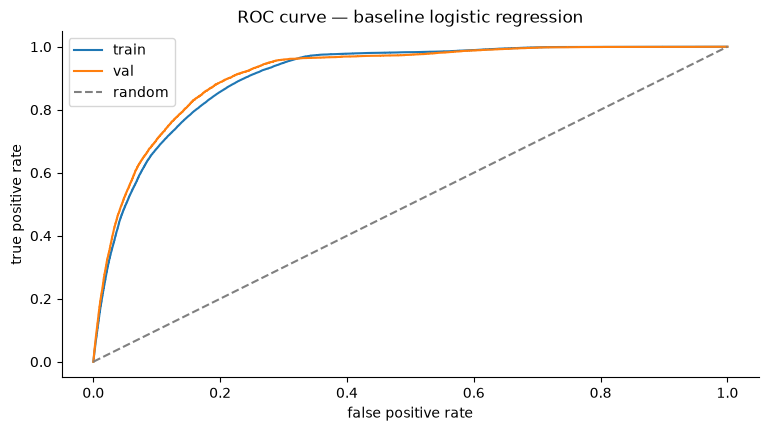

In [8]:
fig, ax = plt.subplots()
for X, y, label in [(X_train_scaled, y_train, "train"), (X_val_scaled, y_val, "val")]:
    scores = model.predict_proba(X)[:, 1]
    fpr, tpr, _ = roc_curve(y, scores)
    ax.plot(fpr, tpr, label=label)
ax.plot([0, 1], [0, 1], linestyle="--", color="grey", label="random")
ax.set_xlabel("false positive rate")
ax.set_ylabel("true positive rate")
ax.set_title("ROC curve — baseline logistic regression")
ax.legend()
plt.show()

### Predicted probability distribution by actual outcome (val)

If the model is separating the classes, adopters' predicted probabilities
should sit meaningfully to the right of non-adopters', even though both
distributions overlap somewhat — adoption is a fundamentally noisy event, not
a deterministic one, so perfect separation was never expected.

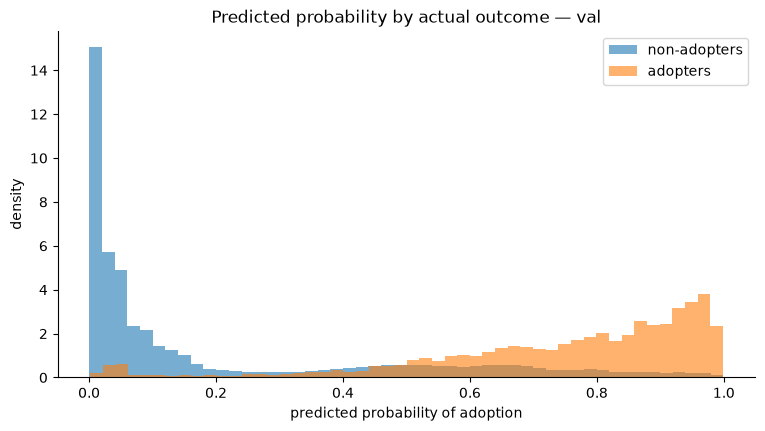

In [9]:
val_scores = model.predict_proba(X_val_scaled)[:, 1]

fig, ax = plt.subplots()
ax.hist(val_scores[y_val == 0], bins=50, alpha=0.6, label="non-adopters", density=True)
ax.hist(val_scores[y_val == 1], bins=50, alpha=0.6, label="adopters", density=True)
ax.set_xlabel("predicted probability of adoption")
ax.set_ylabel("density")
ax.set_title("Predicted probability by actual outcome — val")
ax.legend()
plt.show()

### Coefficients

Because the continuous features were standardized, coefficient magnitudes are
roughly comparable to each other (a one-standard-deviation move in each
feature) — not just their signs. Sorted by absolute value below.


coefficients (log-odds scale, sorted by |value|):
activity_index            1.254854
age_years_sq             -0.760305
age_years                 0.733012
product_count_prev        0.704992
sexo_h                   -0.637006
segmento_universitario   -0.484645
sexo_v                   -0.452650
age_missing              -0.247136
segmento_top             -0.246649
segmento_missing         -0.241853
segmento_particulares    -0.186930
tenure_months             0.118279
renta_missing            -0.091999
renta_log                 0.080585
sexo_missing             -0.070406
tenure_missing           -0.068568
activity_missing         -0.068517
product_count_missing     0.000000


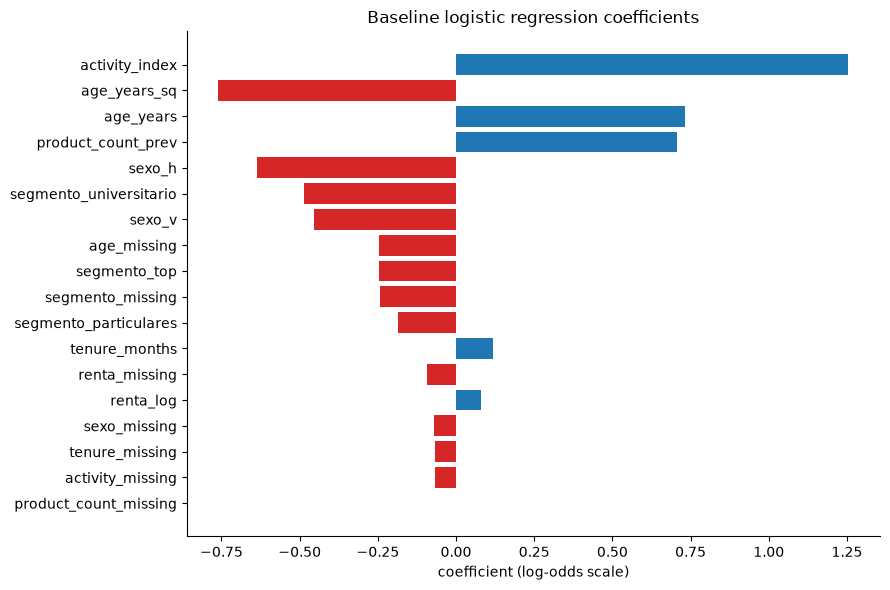

In [10]:
print_coefficients(model)

coefs = pd.Series(model.coef_[0], index=FEATURE_COLS).sort_values(key=abs)
colors = ["#d62728" if c < 0 else "#1f77b4" for c in coefs]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(coefs.index, coefs.values, color=colors)
ax.set_xlabel("coefficient (log-odds scale)")
ax.set_title("Baseline logistic regression coefficients")
plt.tight_layout()
plt.show()

### Lift across different contact budgets (val)

`top_k_lift` was written for a single fixed 1% cutoff; sweeping across a few
budget sizes shows how lift decays as the contact list grows — which is
exactly the shape of question the formal precision@K evaluation (next
session) will answer more rigorously.

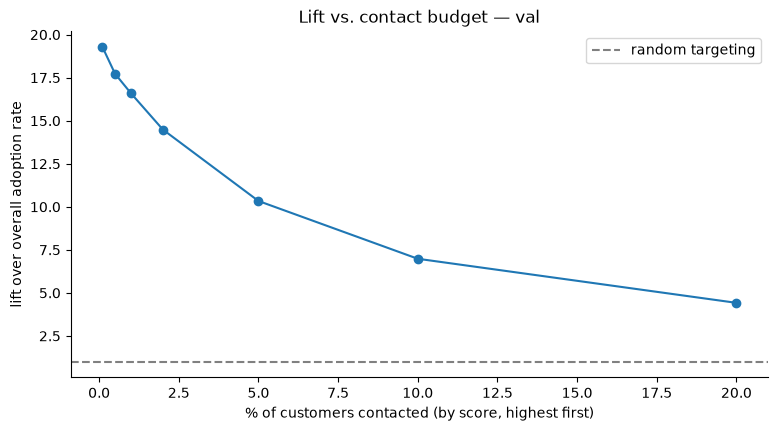

In [11]:
k_fracs = [0.001, 0.005, 0.01, 0.02, 0.05, 0.1, 0.2]
lifts = [top_k_lift(y_val, val_scores, k_frac=k) for k in k_fracs]

fig, ax = plt.subplots()
ax.plot([k * 100 for k in k_fracs], lifts, marker="o")
ax.axhline(1.0, linestyle="--", color="grey", label="random targeting")
ax.set_xlabel("% of customers contacted (by score, highest first)")
ax.set_ylabel("lift over overall adoption rate")
ax.set_title("Lift vs. contact budget — val")
ax.legend()
plt.show()

### Takeaways

- ROC-AUC ~0.91 on val, close to train's ~0.91 — no sign of overfitting at
  this feature count/model complexity.
- Coefficient signs all matched EDA expectations: `activity_index` and
  `product_count_prev` strongly positive; `age_years` positive with
  `age_years_sq` negative, tracing the 45-50 adoption peak as a downward
  parabola.
- Lift decays quickly as the contact budget grows past ~1-2% — expected for a
  rare event, and useful context for Phase 4's targeting-strategy work.
- Next session: fit LightGBM on this same train/val split for a direct
  comparison, then the formal precision@K evaluation (fixed K, both models vs.
  random targeting) reported once on test.